# xresnet1d Training Notebook — DAT255

Training **xresnet1d-50** (Strodthoff et al. 2021 reference architecture for PTB-XL) as an established SOTA baseline to compare our custom CNN / ResCNN / BiLSTM against.

Mirrors `training.ipynb`'s data pipeline (same split, normalisation, augmentation, focal loss) but uses a **revised training recipe** tuned for the larger model:

| | v1 (default) | v2 (this notebook) |
|:--|:--|:--|
| Peak LR | 1e-3 | 3e-4 |
| Schedule | ReduceLROnPlateau | Warmup + cosine decay |
| Epochs | 50 | 80 |
| Block dropout | none | `SpatialDropout1D(0.1)` inside each bottleneck |

Why: xresnet1d-50 has ~11× more parameters than our CNN and was underperforming at F1 due to miscalibration from a too-generic training recipe. These changes address both the undertraining (cosine decay gives a longer productive training tail) and the overconfidence (block dropout regularises the residual representations).

**Outputs** (saved to `artifacts/`):
- `ecg_xresnet1d_final.keras` — best checkpoint by val AUC
- Merged into `histories.pkl` for the comparison notebook

Run this **after** or **instead of** `training.ipynb`. Either works — it's self-contained.

## 1. Setup

In [11]:
import os, json, pickle, random, ast
os.environ.pop("MLFLOW_TRACKING_URI", None)
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import wfdb
import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from sklearn.preprocessing import MultiLabelBinarizer
import warnings

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

ART_DIR = "artifacts"
os.makedirs(ART_DIR, exist_ok=True)

tf.autograph.set_verbosity(0)
warnings.filterwarnings("ignore")

print(f"Keras   : {keras.__version__}")
print(f"TF      : {tf.__version__}")
print(f"Backend : {keras.backend.backend()}")

Keras   : 3.13.2
TF      : 2.21.0
Backend : tensorflow


## 2. Load dataset & build labels

In [12]:
DATA_DIR = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

scp_df = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
scp_df = scp_df[scp_df["diagnostic"] == 1]
code_to_superclass = scp_df["diagnostic_class"].to_dict()

SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
NUM_CLASSES = len(SUPERCLASSES)

def extract_superclasses(scp_dict):
    return list({code_to_superclass[c] for c in scp_dict
                 if c in code_to_superclass})

df["superclasses"] = df["scp_codes"].apply(extract_superclasses)
df = df[df["superclasses"].map(len) > 0].copy()
df = df[df["age"] <= 120].copy()

mlb = MultiLabelBinarizer(classes=SUPERCLASSES)
labels = mlb.fit_transform(df["superclasses"])
df[SUPERCLASSES] = labels

print(f"Samples after filtering: {len(df)}")

Samples after filtering: 21103


In [13]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

def _read_one(path):
    return wfdb.rdrecord(path).p_signal.astype(np.float32)

def load_raw_signals(df, data_dir, cache_path=None, n_workers=8):
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached signals from {cache_path}")
        return np.load(cache_path)
    paths = [os.path.join(data_dir, p) for p in df["filename_lr"].values]
    out = np.empty((len(paths), 1000, 12), dtype=np.float32)
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, sig in enumerate(tqdm(pool.map(_read_one, paths),
                                     total=len(paths), desc="Reading WFDB")):
            out[i] = sig
    if cache_path:
        np.save(cache_path, out)
    return out

cache_path = os.path.join(ART_DIR, f"ptbxl_signals_100hz_{len(df)}.npy")
X_all = load_raw_signals(df, DATA_DIR, cache_path=cache_path)
y_all = labels.astype(np.float32)
print(f"X_all: {X_all.shape}   y_all: {y_all.shape}")

Loading cached signals from artifacts/ptbxl_signals_100hz_21103.npy
X_all: (21103, 1000, 12)   y_all: (21103, 5)


## 3. Split, normalise

In [14]:
folds = df["strat_fold"].values
train_mask = folds <= 8
val_mask   = folds == 9
test_mask  = folds == 10

X_train_raw, y_train = X_all[train_mask], y_all[train_mask]
X_val_raw,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test_raw,  y_test  = X_all[test_mask],  y_all[test_mask]

train_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
train_std  = X_train_raw.std(axis=(0, 1), keepdims=True)
train_std[train_std == 0] = 1.0

def normalise(X):
    return np.clip((X - train_mean) / train_std, -10.0, 10.0)

X_train = normalise(X_train_raw)
X_val   = normalise(X_val_raw)
X_test  = normalise(X_test_raw)

np.savez(os.path.join(ART_DIR, "normalisation_params.npz"),
         mean=train_mean, std=train_std)
np.savez(os.path.join(ART_DIR, "eval_sets.npz"),
         X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)

print(f"Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}")

Train: (16872, 1000, 12)   Val: (2105, 1000, 12)   Test: (2126, 1000, 12)


## 4. Data augmentation

In [15]:
def augment_ecg(x, y):
    if tf.random.uniform(()) < 0.5:
        shift = tf.random.uniform((), -50, 51, dtype=tf.int32)
        x = tf.roll(x, shift, axis=0)
    if tf.random.uniform(()) < 0.5:
        x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=0.02)
    if tf.random.uniform(()) < 0.5:
        scale = tf.random.uniform((), 0.9, 1.1)
        x = x * scale
    return x, y


def make_dataset(X, y, batch_size=64, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 2048), seed=SEED)
    if augment:
        ds = ds.map(augment_ecg, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


BATCH_SIZE = 64  # drop to 32 if GPU OOM (xresnet1d-50 is ~11M params)
train_ds = make_dataset(X_train, y_train, BATCH_SIZE, augment=True, shuffle=True)
val_ds   = make_dataset(X_val, y_val, BATCH_SIZE)
test_ds  = make_dataset(X_test, y_test, BATCH_SIZE)

## 5. Focal Loss

In [16]:
def binary_focal_loss(alpha=0.25, gamma=2.0):
    def loss_fn(y_true, y_pred):
        eps = keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1.0 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1.0 - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1.0 - pt, gamma) * tf.math.log(pt))
    loss_fn.__name__ = "binary_focal_loss"
    return loss_fn

## 6. xresnet1d-50 model

"Bag of Tricks" ResNet (He 2019) adapted to 1D. See Strodthoff et al. 2021.

Changes from vanilla ResNet-50:
- **xresnet stem**: 3 convs (32 → 32 → 64) instead of one wide conv
- **ResNet-D shortcut**: AvgPool + 1×1 instead of strided 1×1
- **Zero-init gamma** on the last BN of each block — block starts as identity
- **Kernel 5** throughout (suits 100 Hz ECG morphology)
- **New in v2**: optional `block_dropout` via `SpatialDropout1D` after each residual add. Tames overconfidence in the 11M-param network.

In [17]:
INPUT_SHAPE = (1000, 12)


def _conv_bn(x, filters, kernel_size, strides=1, gamma_init="ones"):
    x = layers.Conv1D(filters, kernel_size, strides=strides,
                      padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(gamma_initializer=gamma_init)(x)
    return x


def _conv_bn_relu(x, filters, kernel_size, strides=1):
    return layers.Activation("relu")(_conv_bn(x, filters, kernel_size, strides))


def _stem(x, base=64):
    x = _conv_bn_relu(x, base // 2, 5, strides=2)
    x = _conv_bn_relu(x, base // 2, 5)
    x = _conv_bn_relu(x, base,       5)
    x = layers.MaxPooling1D(3, strides=2, padding="same")(x)
    return x


def _bottleneck_block(x, filters, strides=1, expansion=4, block_dropout=0.0):
    """Bottleneck with optional SpatialDropout1D after the residual add."""
    out_filters = filters * expansion
    in_filters = x.shape[-1]
    y = _conv_bn_relu(x, filters, 1)
    y = _conv_bn_relu(y, filters, 5, strides=strides)
    y = _conv_bn(y, out_filters, 1, gamma_init="zeros")
    if strides != 1 or in_filters != out_filters:
        if strides != 1:
            x = layers.AveragePooling1D(pool_size=strides, strides=strides,
                                        padding="same")(x)
        x = _conv_bn(x, out_filters, 1)
    x = layers.Add()([x, y])
    x = layers.Activation("relu")(x)
    if block_dropout > 0:
        x = layers.SpatialDropout1D(block_dropout)(x)
    return x


def build_xresnet1d(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, dropout=0.3,
                    blocks=(3, 4, 6, 3),
                    stage_filters=(64, 128, 256, 512),
                    block_dropout=0.1):
    """xresnet1d-50 default. Pass blocks=(3,4,23,3) for xresnet1d-101.
    block_dropout: SpatialDropout1D rate inside each residual block (v2 addition).
    """
    inputs = keras.Input(shape=input_shape, name="ecg_input")
    x = _stem(inputs)
    for stage_idx, (n_blocks, filters) in enumerate(zip(blocks, stage_filters)):
        for b in range(n_blocks):
            stride = 2 if (b == 0 and stage_idx > 0) else 1
            x = _bottleneck_block(x, filters, strides=stride,
                                  block_dropout=block_dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid",
                           name="predictions")(x)
    model_name = f"xresnet1d{sum(blocks) * 3 + 2}"
    return keras.Model(inputs, outputs, name=model_name)


_m = build_xresnet1d()
_last_conv = next(l.name for l in reversed(_m.layers)
                  if isinstance(l, layers.Conv1D))
print(f"{_m.name:14s}  params={_m.count_params():>11,}  "
      f"gradcam_layer={_last_conv}")
del _m

xresnet1d50     params= 18,549,637  gradcam_layer=conv1d_164


## 7. LR schedule — warmup + cosine decay

`ReduceLROnPlateau` is reactive; cosine decay plans ahead. Typical pattern for training bigger networks: 3–5 epochs of linear warmup (lets BN statistics stabilise before the LR gets big), then cosine decay down to ~1% of peak.

This is implemented as a `LearningRateSchedule` passed to the Adam optimiser, not a callback, so it updates on every step rather than every epoch.

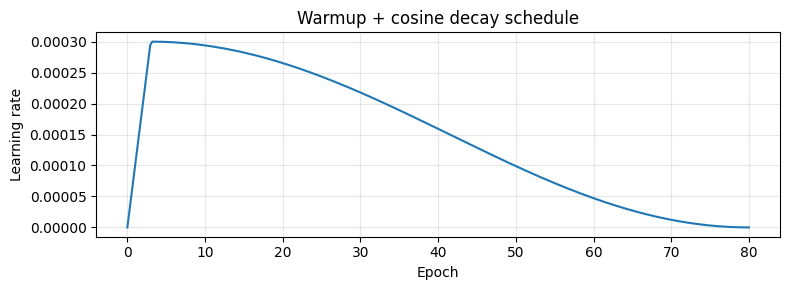

In [18]:
import math

class WarmupCosine(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup to peak_lr over warmup_steps, then cosine decay
    to end_lr over remaining (total_steps - warmup_steps) steps."""
    def __init__(self, peak_lr, warmup_steps, total_steps, end_lr=0.0):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps  = int(total_steps)
        self.end_lr       = float(end_lr)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = tf.cast(self.warmup_steps, tf.float32)
        total  = tf.cast(self.total_steps,  tf.float32)

        # Linear warmup phase
        warmup_lr = self.peak_lr * (step / tf.maximum(warmup, 1.0))

        # Cosine decay phase
        progress = (step - warmup) / tf.maximum(total - warmup, 1.0)
        progress = tf.clip_by_value(progress, 0.0, 1.0)
        cosine_lr = self.end_lr + 0.5 * (self.peak_lr - self.end_lr) * \
                    (1.0 + tf.cos(math.pi * progress))

        return tf.where(step < warmup, warmup_lr, cosine_lr)

    def get_config(self):
        return {"peak_lr": self.peak_lr,
                "warmup_steps": self.warmup_steps,
                "total_steps": self.total_steps,
                "end_lr": self.end_lr}


# Quick visual sanity check
import matplotlib.pyplot as plt
_steps_per_epoch = len(X_train) // BATCH_SIZE
_total = _steps_per_epoch * 80
_warmup = _steps_per_epoch * 3
_sched = WarmupCosine(peak_lr=3e-4, warmup_steps=_warmup, total_steps=_total)
_xs = np.linspace(0, _total, 300)
_ys = [float(_sched(s)) for s in _xs]
plt.figure(figsize=(8, 3))
plt.plot(_xs / _steps_per_epoch, _ys)
plt.xlabel("Epoch"); plt.ylabel("Learning rate"); plt.grid(alpha=0.3)
plt.title("Warmup + cosine decay schedule")
plt.tight_layout(); plt.show()

## 8. Training

In [19]:
try:
    import mlflow
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("ECG_PTBXL_Final")
    USE_MLFLOW = True
except Exception as e:
    print(f"MLflow not available ({e}); continuing without tracking.")
    USE_MLFLOW = False


def train_xresnet(model, name, peak_lr=3e-4, warmup_epochs=3, epochs=80):
    """Tuned training recipe for xresnet1d-50:
       - cosine decay LR from peak_lr to ~0
       - warmup over warmup_epochs
       - ModelCheckpoint on val_auc (EarlyStopping removed — the schedule
         is planned, so letting it finish is important).
    """
    steps_per_epoch = len(X_train) // BATCH_SIZE
    total_steps  = steps_per_epoch * epochs
    warmup_steps = steps_per_epoch * warmup_epochs
    schedule = WarmupCosine(peak_lr=peak_lr,
                            warmup_steps=warmup_steps,
                            total_steps=total_steps,
                            end_lr=peak_lr * 0.01)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=schedule),
        loss=binary_focal_loss(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", multi_label=True),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    ckpt_path = os.path.join(ART_DIR, f"ecg_{name}_final.keras")
    cb = [
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_auc", mode="max",
                                  save_best_only=True, verbose=1),
    ]

    if USE_MLFLOW:
        with mlflow.start_run(run_name=name):
            mlflow.log_params({
                "loss": "focal", "peak_lr": peak_lr,
                "warmup_epochs": warmup_epochs, "epochs": epochs,
                "schedule": "warmup_cosine",
                "block_dropout": 0.1,
                "n_params": model.count_params(),
            })
            history = model.fit(train_ds, validation_data=val_ds,
                                epochs=epochs, callbacks=cb, verbose=2)
            for k, v in history.history.items():
                for i, val in enumerate(v):
                    mlflow.log_metric(k, val, step=i)
    else:
        history = model.fit(train_ds, validation_data=val_ds,
                            epochs=epochs, callbacks=cb, verbose=2)
    return history

In [20]:
# Build xresnet1d-50 with block dropout and train with warmup + cosine schedule
xresnet_model = build_xresnet1d(dropout=0.3, block_dropout=0.1)
xresnet_history = train_xresnet(xresnet_model, "xresnet1d",
                                peak_lr=3e-4, warmup_epochs=3, epochs=80)

Epoch 1/80

Epoch 1: val_auc improved from None to 0.79155, saving model to artifacts/ecg_xresnet1d_final.keras

Epoch 1: finished saving model to artifacts/ecg_xresnet1d_final.keras
264/264 - 65s - 247ms/step - accuracy: 0.6764 - auc: 0.5396 - loss: 0.1062 - precision: 0.3148 - recall: 0.2131 - val_accuracy: 0.7561 - val_auc: 0.7915 - val_loss: 0.0478 - val_precision: 0.8531 - val_recall: 0.0663
Epoch 2/80

Epoch 2: val_auc improved from 0.79155 to 0.83246, saving model to artifacts/ecg_xresnet1d_final.keras

Epoch 2: finished saving model to artifacts/ecg_xresnet1d_final.keras
264/264 - 18s - 69ms/step - accuracy: 0.7656 - auc: 0.6841 - loss: 0.0675 - precision: 0.6161 - recall: 0.2496 - val_accuracy: 0.8177 - val_auc: 0.8325 - val_loss: 0.0428 - val_precision: 0.7945 - val_recall: 0.3958
Epoch 3/80

Epoch 3: val_auc improved from 0.83246 to 0.85745, saving model to artifacts/ecg_xresnet1d_final.keras

Epoch 3: finished saving model to artifacts/ecg_xresnet1d_final.keras
264/264 - 19

## 9. Merge into `histories.pkl`

If `training.ipynb` has already been run, this adds `xresnet1d` to the existing histories dict. If not, it creates a new one with just `xresnet1d`. `model_comparison.ipynb` will pick up whatever is present.

In [21]:
hist_path = os.path.join(ART_DIR, "histories.pkl")
if os.path.exists(hist_path):
    with open(hist_path, "rb") as f:
        histories = pickle.load(f)
    print(f"Loaded existing histories.pkl with keys: {list(histories.keys())}")
else:
    histories = {}
    print("No existing histories.pkl — creating new one")

histories["xresnet1d"] = xresnet_history.history
with open(hist_path, "wb") as f:
    pickle.dump(histories, f)

print(f"\nhistories.pkl now has: {list(histories.keys())}")
print("\nArtifacts dir:")
for f in sorted(os.listdir(ART_DIR)):
    size_mb = os.path.getsize(os.path.join(ART_DIR, f)) / 1e6
    print(f"  {f:45s} {size_mb:>8.2f} MB")

Loaded existing histories.pkl with keys: ['cnn', 'rescnn', 'lstm', 'xresnet1d']

histories.pkl now has: ['cnn', 'rescnn', 'lstm', 'xresnet1d']

Artifacts dir:
  ecg_cnn_final.keras                               2.42 MB
  ecg_lstm_final.keras                              7.27 MB
  ecg_rescnn_final.keras                           19.54 MB
  ecg_xresnet1d_final.keras                       222.99 MB
  eval_sets.npz                                   203.17 MB
  histories.pkl                                     0.02 MB
  normalisation_params.npz                          0.00 MB
  ptbxl_signals_100hz.npy                        1012.94 MB
  ptbxl_signals_100hz_21103.npy                  1012.94 MB
  thresholds.json                                   0.00 MB
  tuner_results.json                                0.00 MB


---

**Done.** Run `model_comparison.ipynb` to see xresnet1d alongside your other models.